## Portfolio archive and evaluation note

This notebook is retained as part of the original MRI denoising experiment suite. Saved cells and outputs are included so the development work can be reviewed without rerunning long GPU training jobs.

> **Evaluation limitation:** In the supplied workflow, several experiments use the same image directory for both training and validation. The stored metrics are therefore historical development results, not independently reproduced estimates from a held-out validation set. A reliable rerun should use patient-level train, validation, and test splits.

The code was developed in Google Colab and contains hard-coded paths under `/content/drive/MyDrive/Final RI/`. Update those paths before running it with your own dataset.


In [ ]:
# ===========================
#  Cell 1: Periodic-Only Noise with Logging
# ===========================
import os, cv2, numpy as np, glob, random, zipfile, pandas as pd
from tqdm import tqdm
from google.colab import drive

# --- 1. Mount Google Drive for data access ---
drive.mount('/content/drive')

# --- 2. Extract dataset if not already extracted ---
zip_path = "/content/drive/MyDrive/Final RI/glioma.zip"
extract_path = "/content/drive/MyDrive/Final RI/glioma"
if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(" Extracted glioma.zip to:", extract_path)
else:
    print(" glioma/ already exists. Skipping extraction.")

# --- 3. Define clean and Periodic-noisy image directories ---
CLEAN_DIR = extract_path
NOISY_DIR = "/content/drive/MyDrive/Final RI/single_noise_outputs/single_noise_outputs_periodic"
os.makedirs(NOISY_DIR, exist_ok=True)

# --- 4. Set random seeds for reproducibility ---
random.seed(42)
np.random.seed(42)

# --- 5. Define periodic artifact function (realistic Siemens-style) ---
def safe_clip(img):
    return np.clip(img, 1e-6, 1.0)

def add_periodic_artifact(img, freq=6, amplitude=0.05):
    rows, cols = img.shape
    x = np.arange(cols)
    y = np.arange(rows)
    xv, yv = np.meshgrid(x, y)
    sinusoid = amplitude * np.sin(2 * np.pi * freq * xv / cols)
    return safe_clip(img + sinusoid)

# --- 6. Generate and save periodic-noised versions of all images ---
image_paths = sorted(glob.glob(os.path.join(CLEAN_DIR, "*.*")))
log_data = []

print(f" Found {len(image_paths)} clean images to process")

for img_path in tqdm(image_paths, desc=" Adding realistic-style Periodic noise only"):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f" Skipping unreadable file: {img_path}")
        continue

    img = cv2.resize(img, (256, 256)).astype(np.float32) / 255.0

    #  Apply periodic artifact only (realistic Siemens-style)
    img_noisy = add_periodic_artifact(img, freq=6, amplitude=0.05)
    noise_types = [f"Periodic(freq=6, amp=0.05)"]

    out_path = os.path.join(NOISY_DIR, os.path.basename(img_path))
    img_save = (img_noisy * 255).astype(np.uint8)
    cv2.imwrite(out_path, img_save)

    log_data.append({
        "filename": os.path.basename(img_path),
        "noise_types": " + ".join(noise_types)
    })

# --- 7. Save noise log as CSV for reproducibility and analysis ---
log_df = pd.DataFrame(log_data)
csv_path = os.path.join(NOISY_DIR, "noise_log.csv")
log_df.to_csv(csv_path, index=False)

print(f" Periodic-noised images saved to: {NOISY_DIR}")
print(f" Noise log saved to: {csv_path}")


Mounted at /content/drive
✅ Extracted glioma.zip to: /content/drive/MyDrive/Final RI/glioma
🔍 Found 1297 clean images to process


🔧 Adding realistic-style Periodic noise only: 100%|██████████| 1297/1297 [00:27<00:00, 46.85it/s]

✅ Periodic-noised images saved to: /content/drive/MyDrive/Final RI/single_noise_outputs/single_noise_outputs_periodic
📄 Noise log saved to: /content/drive/MyDrive/Final RI/single_noise_outputs/single_noise_outputs_periodic/noise_log.csv


In [ ]:
# ===========================
#  Cell 2: Dataset Loader for Periodic-Only Denoising
# ===========================
import torch
from torch.utils.data import Dataset
from torchvision import transforms
import os, cv2, numpy as np
import glob

# --- Define preprocessing transformation: converts grayscale images to tensors ---
transform = transforms.Compose([
    transforms.ToTensor(),  # Converts (H, W) to (1, H, W) float32 in [0, 1]
])

# --- Dataset class for paired MRI noisy-clean image loading ---
class MRIDenoisingDataset(Dataset):
    def __init__(self, noisy_dir, clean_dir, transform=None):
        # Collect all image file paths from noisy and clean directories
        noisy_all = sorted(glob.glob(os.path.join(noisy_dir, "*.*")))
        clean_all = sorted(glob.glob(os.path.join(clean_dir, "*.*")))

        # Filter and index image files by filename
        noisy_dict = {os.path.basename(p): p for p in noisy_all if p.lower().endswith(('.png', '.jpg', '.jpeg'))}
        clean_dict = {os.path.basename(p): p for p in clean_all if p.lower().endswith(('.png', '.jpg', '.jpeg'))}

        # Find common image filenames present in both directories
        common_filenames = sorted(set(noisy_dict.keys()) & set(clean_dict.keys()))
        assert common_filenames, " No matching image files found between noisy and clean dirs."

        # Store matched paths
        self.noisy_paths = [noisy_dict[f] for f in common_filenames]
        self.clean_paths = [clean_dict[f] for f in common_filenames]
        self.transform = transform

        print(f"[INFO]  Matched {len(self.noisy_paths)} image pairs.")

    def __len__(self):
        return len(self.noisy_paths)

    def __getitem__(self, idx):
        noisy_path = self.noisy_paths[idx]
        clean_path = self.clean_paths[idx]

        # Load images in grayscale
        noisy = cv2.imread(noisy_path, cv2.IMREAD_GRAYSCALE)
        clean = cv2.imread(clean_path, cv2.IMREAD_GRAYSCALE)

        if noisy is None or clean is None:
            raise ValueError(f"Invalid image: {noisy_path} or {clean_path}")

        # Resize to 256x256 and normalize to [0, 1]
        noisy = cv2.resize(noisy, (256, 256)).astype(np.float32) / 255.0
        clean = cv2.resize(clean, (256, 256)).astype(np.float32) / 255.0

        # Apply defined transform (e.g., ToTensor)
        if self.transform:
            noisy = self.transform(noisy)
            clean = self.transform(clean)

        return noisy, clean

# --- Define training and validation directory paths (Periodic-only) ---
train_noisy_dir = "/content/drive/MyDrive/Final RI/single_noise_outputs/single_noise_outputs_periodic"
val_noisy_dir   = "/content/drive/MyDrive/Final RI/single_noise_outputs/single_noise_outputs_periodic"
train_clean_dir = "/content/drive/MyDrive/Final RI/glioma"
val_clean_dir   = "/content/drive/MyDrive/Final RI/glioma"

# --- Create dataset objects for training and validation ---
train_dataset = MRIDenoisingDataset(train_noisy_dir, train_clean_dir, transform)
val_dataset   = MRIDenoisingDataset(val_noisy_dir, val_clean_dir, transform)

print(f"[INFO]  Loaded {len(train_dataset)} training images")
print(f"[INFO]  Loaded {len(val_dataset)} validation images")


[INFO] ✅ Matched 1297 image pairs.
[INFO] ✅ Matched 1297 image pairs.
[INFO] ✅ Loaded 1297 training images
[INFO] ✅ Loaded 1297 validation images


In [ ]:
# ===========================
#  Cell 3: Generator – VAE-integrated U-Net Architecture
#  Patched with full NaN-safe latent + output handling
# ===========================
import torch
import torch.nn as nn
import torch.nn.functional as F

# --- Convolutional block with Instance Normalization and LeakyReLU activation ---
def conv_block(in_channels, out_channels, kernel_size=3, stride=1, padding=1):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding),
        nn.InstanceNorm2d(out_channels),
        nn.LeakyReLU(0.2, inplace=True)
    )

# --- VAE + U-Net based Generator ---
class UNetGenerator(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, latent_dim=256):
        super(UNetGenerator, self).__init__()

        # --- Encoder ---
        self.enc1 = conv_block(in_channels, 64)
        self.enc2 = conv_block(64, 128)
        self.enc3 = conv_block(128, 256)
        self.enc4 = conv_block(256, 512)
        self.pool = nn.MaxPool2d(2)

        # --- Bottleneck ---
        self.flatten = nn.Flatten()
        self.fc_mu = nn.Linear(512 * 16 * 16, latent_dim)
        self.fc_logvar = nn.Linear(512 * 16 * 16, latent_dim)
        self.fc_decoder = nn.Linear(latent_dim, 512 * 16 * 16)
        self.unflatten = nn.Unflatten(1, (512, 16, 16))

        # --- Decoder ---
        self.up1 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec1 = conv_block(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = conv_block(256, 128)

        self.up3 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec3 = conv_block(128, 64)

        self.out_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        # --- Encoder ---
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        e4_pool = self.pool(e4)

        # --- Latent space ---
        flat = self.flatten(e4_pool)
        mu = self.fc_mu(flat)
        logvar = self.fc_logvar(flat)

        #  NaN and overflow protection
        mu = torch.nan_to_num(mu, nan=0.0)
        logvar = torch.nan_to_num(logvar, nan=0.0)
        logvar = torch.clamp(logvar, min=-20.0, max=20.0)

        z = self.reparameterize(mu, logvar)
        z = self.unflatten(self.fc_decoder(z))
        z = F.interpolate(z, size=(32, 32), mode='bilinear', align_corners=False)

        # --- Decoder ---
        d1 = self.up1(z)
        d1 = self.dec1(torch.cat([d1, e3], dim=1))

        d2 = self.up2(d1)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d3 = self.up3(d2)
        d3 = self.dec3(torch.cat([d3, e1], dim=1))

        out = torch.sigmoid(self.out_conv(d3))

        #  Protect against NaNs in output
        if torch.isnan(out).any():
            print(" Generator output contains NaN – replacing with zeros")
            out = torch.zeros_like(out)

        return out, mu, logvar


In [ ]:
# ===========================
#  Cell 4: DWT + PatchGAN Discriminator
# ===========================
import torch
import torch.nn as nn
import torch.nn.functional as F
import pywt
import numpy as np

# --- Discrete Wavelet Transform (DWT) Layer: Extracts LL, LH, HL, HH components per channel ---
class DWT_2D(nn.Module):
    def __init__(self, wave='haar'):
        super(DWT_2D, self).__init__()
        self.wave = wave

    def forward(self, x):
        B, C, H, W = x.shape
        dwt_output = []
        for b in range(B):
            channels = []
            for c in range(C):
                arr = x[b, c].detach().cpu().numpy()
                LL, (LH, HL, HH) = pywt.dwt2(arr, self.wave)
                channels.extend([LL, LH, HL, HH])
            stacked = np.stack(channels)
            dwt_output.append(torch.from_numpy(stacked).float())
        return torch.stack(dwt_output).to(x.device)

# --- PatchGAN-style Discriminator that operates on DWT frequency components ---
class Discriminator(nn.Module):
    def __init__(self, in_channels=1):
        super(Discriminator, self).__init__()
        self.dwt = DWT_2D()

        self.net = nn.Sequential(
            nn.Conv2d(4, 64, kernel_size=4, stride=2, padding=1),  # Input channels: 4 = LL, LH, HL, HH
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.InstanceNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.InstanceNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1),
            nn.InstanceNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(512, 1, kernel_size=4, stride=1, padding=1)  # Outputs patch-level real/fake scores
        )

    def forward(self, x):
        with torch.no_grad():  # Freeze DWT operation for inference-only feature extraction
            x = self.dwt(x)    # Convert input to DWT frequency representation [B, 4, H/2, W/2]
        return self.net(x)


In [ ]:
# ===========================
#  Cell 5: Loss Functions – Combined L1, SSIM, GAN, and Clipped KL
#  Patched to fix NaNs from logvar.exp() and reduce KL weight
# ===========================

!pip install pytorch-ssim

import torch
import torch.nn as nn
import torch.nn.functional as F
import pytorch_ssim  # SSIM loss implementation

# --- Initialize individual loss components ---
l1_criterion = nn.L1Loss()                           # Pixel-wise L1 loss
ssim_criterion = pytorch_ssim.SSIM(window_size=11)   # Structural similarity loss
bce_criterion = nn.BCEWithLogitsLoss()               # Binary cross-entropy for GAN

# --- KL divergence with clamped logvar to prevent exp overflow and NaN ---
def kl_divergence(mu, logvar):
    logvar = torch.clamp(logvar, min=-20.0, max=20.0)
    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return torch.clamp(kl, max=1000.0)

# --- Discriminator loss using BCE for real vs. fake classification ---
def get_discriminator_loss(D, real_imgs, fake_imgs):
    real_preds = D(real_imgs)
    fake_preds = D(fake_imgs.detach())

    real_labels = torch.ones_like(real_preds)
    fake_labels = torch.zeros_like(fake_preds)

    real_loss = bce_criterion(real_preds, real_labels)
    fake_loss = bce_criterion(fake_preds, fake_labels)

    return 0.5 * (real_loss + fake_loss)

# --- Generator loss: weighted combination of L1, SSIM, adversarial, and KL divergence losses ---
def get_generator_loss(D, fake_imgs, real_imgs, mu, logvar):
    pred_fake = D(fake_imgs)
    adv_loss  = bce_criterion(pred_fake, torch.ones_like(pred_fake))
    l1_loss   = l1_criterion(fake_imgs, real_imgs)
    ssim_loss = 1 - ssim_criterion(fake_imgs, real_imgs)
    kl_loss   = kl_divergence(mu, logvar)

    total_loss = 5.0 * l1_loss + 10.0 * ssim_loss + 0.5 * adv_loss + 0.001 * kl_loss

    return total_loss, {
        "L1": l1_loss.item(),
        "SSIM": 1 - ssim_loss.item(),
        "Adv": adv_loss.item(),
        "KL": kl_loss.item()
    }


  Preparing metadata (setup.py) ... done
  Created wheel for pytorch-ssim: filename=pytorch_ssim-0.1-py3-none-any.whl size=2006 sha256=bec326f26477fc880d4bed59eb26da89dfaccbadc343e8fc413176baff9c4427
  Stored in directory: /root/.cache/pip/wheels/54/a0/11/99f86224e71729ed9ef0c4ffe1b795807ad5f44bde19bc66f9
Successfully built pytorch-ssim


In [ ]:
# ================================
#  Patch for SSIM: Fixes padding behavior and ensures correct device placement
# ================================
import pytorch_ssim
import torch.nn.functional as F

# --- Custom SSIM function with corrected padding and device handling ---
def fixed_ssim(img1, img2, window, window_size, channel, size_average=True):
    padding = int(window_size // 2)

    # Ensure the convolution window is on the same device as the input tensors
    window = window.to(img1.device)

    mu1 = F.conv2d(img1, window, padding=padding, groups=channel)
    mu2 = F.conv2d(img2, window, padding=padding, groups=channel)

    mu1_sq = mu1.pow(2)
    mu2_sq = mu2.pow(2)
    mu1_mu2 = mu1 * mu2

    sigma1_sq = F.conv2d(img1 * img1, window, padding=padding, groups=channel) - mu1_sq
    sigma2_sq = F.conv2d(img2 * img2, window, padding=padding, groups=channel) - mu2_sq
    sigma12  = F.conv2d(img1 * img2, window, padding=padding, groups=channel) - mu1_mu2

    C1 = 0.01 ** 2
    C2 = 0.03 ** 2

    # Compute SSIM map
    ssim_map = ((2 * mu1_mu2 + C1) * (2 * sigma12 + C2)) / \
               ((mu1_sq + mu2_sq + C1) * (sigma1_sq + sigma2_sq + C2))

    return ssim_map.mean() if size_average else ssim_map.mean(1).mean(1).mean(1)

# --- Override original SSIM function with fixed version ---
pytorch_ssim._ssim = fixed_ssim


In [ ]:
# ===========================
#  Cell 6: Training Loop with KL Loss, PSNR/SSIM Evaluation, and Stability Checks
#  Patched to Fix NaN in D loss (Periodic-only safe)
# ===========================

import os
import glob
import torch
from torch.utils.data import DataLoader
import numpy as np
from skimage.metrics import peak_signal_noise_ratio as compute_psnr
from skimage.metrics import structural_similarity as compute_ssim
from tqdm import tqdm

# ---  Reproducibility Settings ---
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

#  Enable anomaly detection to debug future NaNs
torch.autograd.set_detect_anomaly(True)

# --- Initialize Data Loaders ---
BATCH_SIZE = 4
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=1, shuffle=False)

# --- Initialize Models and Optimizers ---
G = UNetGenerator().cuda()
D = Discriminator().cuda()
g_optimizer = torch.optim.Adam(G.parameters(), lr=1e-4)
d_optimizer = torch.optim.Adam(D.parameters(), lr=1e-5)

# ---  Set Save Directory and Best Metric Tracker for Periodic ---
SAVE_PATH = "/content/drive/MyDrive/Final RI/checkpoints/periodic"
os.makedirs(SAVE_PATH, exist_ok=True)
BEST_SSIM = 0.0

# --- Training Function ---
def train(epochs):
    global BEST_SSIM
    for epoch in range(1, epochs + 1):
        G.train()
        D.train()
        running_g_loss = 0.0
        running_d_loss = 0.0

        loop = tqdm(train_loader, desc=f" Epoch [{epoch}/{epochs}]")
        for noisy_imgs, clean_imgs in loop:
            noisy_imgs = noisy_imgs.cuda(non_blocking=True)
            clean_imgs = clean_imgs.cuda(non_blocking=True)

            # --- Discriminator Update ---
            if epoch <= 3:
                d_loss = torch.tensor(0.0).cuda()  # Freeze D for first 3 epochs to prevent collapse
            else:
                D.zero_grad()
                fake_imgs, _, _ = G(noisy_imgs)
                d_loss = get_discriminator_loss(D, clean_imgs, fake_imgs)

                if torch.isnan(d_loss) or torch.isinf(d_loss):
                    print(" Skipping batch: NaN in D loss")
                    continue

                d_loss.backward()
                d_optimizer.step()

            # --- Generator Update ---
            G.zero_grad()
            fake_imgs, mu, logvar = G(noisy_imgs)
            g_loss, g_loss_dict = get_generator_loss(D, fake_imgs, clean_imgs, mu, logvar)

            if torch.isnan(g_loss) or torch.isinf(g_loss):
                print(" Skipping batch: NaN in G loss")
                continue

            g_loss.backward()
            g_optimizer.step()

            running_g_loss += g_loss.item()
            running_d_loss += d_loss.item()

            loop.set_postfix({
                "G_loss": f"{g_loss.item():.4f}",
                "D_loss": f"{d_loss.item():.4f}",
                "KL": f"{g_loss_dict['KL']:.2f}",
                "PSNR": "-",
                "SSIM": "-"
            })

        # --- Validation Phase ---
        G.eval()
        total_psnr = 0.0
        total_ssim = 0.0
        valid_batches = 0

        with torch.no_grad():
            for noisy_imgs, clean_imgs in val_loader:
                noisy_imgs = noisy_imgs.cuda()
                clean_imgs = clean_imgs.cuda()
                fake_imgs, _, _ = G(noisy_imgs)

                pred_np = fake_imgs.squeeze().cpu().numpy()
                target_np = clean_imgs.squeeze().cpu().numpy()

                if np.isnan(pred_np).any() or np.isnan(target_np).any():
                    print(" Skipping NaN in validation output")
                    continue

                try:
                    psnr = compute_psnr(target_np, pred_np, data_range=1.0)
                    ssim = compute_ssim(target_np, pred_np, data_range=1.0)
                    total_psnr += psnr
                    total_ssim += ssim
                    valid_batches += 1
                except:
                    print(" Skipping invalid PSNR/SSIM batch")
                    continue

        if valid_batches > 0:
            avg_psnr = total_psnr / valid_batches
            avg_ssim = total_ssim / valid_batches
        else:
            avg_psnr = float("nan")
            avg_ssim = float("nan")

        # --- Epoch Summary ---
        print(f"\n Epoch {epoch}/{epochs} Summary:")
        print(f"   Generator Loss:     {running_g_loss / len(train_loader):.4f}")
        print(f"   Discriminator Loss: {running_d_loss / len(train_loader):.4f}")
        print(f"   Validation PSNR:    {avg_psnr:.2f} dB")
        print(f"   Validation SSIM:    {avg_ssim:.4f}")

        # --- Save Best Generator Based on SSIM ---
        if avg_ssim > BEST_SSIM:
            BEST_SSIM = avg_ssim

            #  Save the new best checkpoint first
            best_path = os.path.join(SAVE_PATH, f"best_generator_epoch{epoch}_ssim{avg_ssim:.4f}.pt")
            torch.save(G.state_dict(), best_path)
            print(f" Best generator saved: {os.path.basename(best_path)} (SSIM: {avg_ssim:.4f})")

            #  Delete all *other* previous best checkpoints (keep only latest one)
            existing_ckpts = sorted(glob.glob(os.path.join(SAVE_PATH, "best_generator_epoch*.pt")), key=os.path.getctime)
            for ckpt in existing_ckpts[:-1]:  # keep only latest
                try:
                    os.remove(ckpt)
                    print(f" Deleted old checkpoint: {os.path.basename(ckpt)}")
                except Exception as e:
                    print(f" Failed to delete {ckpt}: {e}")


# --- Start Training ---
train(epochs=30)


🧪 Epoch [1/30]: 100%|██████████| 325/325 [01:36<00:00,  3.38it/s, G_loss=5.8314, D_loss=0.0000, KL=80.54, PSNR=-, SSIM=-]



✅ Epoch 1/30 Summary:
   Generator Loss:     6.4575
   Discriminator Loss: 0.0000
   Validation PSNR:    6.58 dB
   Validation SSIM:    0.6704
✅ Best generator saved: best_generator_epoch1_ssim0.6704.pt (SSIM: 0.6704)


🧪 Epoch [2/30]: 100%|██████████| 325/325 [01:21<00:00,  4.00it/s, G_loss=2.5441, D_loss=0.0000, KL=64.68, PSNR=-, SSIM=-]



✅ Epoch 2/30 Summary:
   Generator Loss:     4.4763
   Discriminator Loss: 0.0000
   Validation PSNR:    9.12 dB
   Validation SSIM:    0.7517
✅ Best generator saved: best_generator_epoch2_ssim0.7517.pt (SSIM: 0.7517)
🗑️ Deleted old checkpoint: best_generator_epoch1_ssim0.6704.pt


🧪 Epoch [3/30]: 100%|██████████| 325/325 [01:20<00:00,  4.05it/s, G_loss=2.5443, D_loss=0.0000, KL=44.24, PSNR=-, SSIM=-]


...


✅ Epoch 28/30 Summary:
   Generator Loss:     4.2229
   Discriminator Loss: 0.0119
   Validation PSNR:    35.66 dB
   Validation SSIM:    0.9877


🧪 Epoch [29/30]: 100%|██████████| 325/325 [01:51<00:00,  2.91it/s, G_loss=4.4411, D_loss=0.0003, KL=20.35, PSNR=-, SSIM=-]



✅ Epoch 29/30 Summary:
   Generator Loss:     4.1724
   Discriminator Loss: 0.0161
   Validation PSNR:    35.90 dB
   Validation SSIM:    0.9892


🧪 Epoch [30/30]: 100%|██████████| 325/325 [01:52<00:00,  2.89it/s, G_loss=3.6051, D_loss=0.0012, KL=87.15, PSNR=-, SSIM=-]



✅ Epoch 30/30 Summary:
   Generator Loss:     4.1761
   Discriminator Loss: 0.0210
   Validation PSNR:    36.24 dB
   Validation SSIM:    0.9884


In [ ]:
# ===========================
#  Cell 7: Inference on Periodic-Only Denoising (PSNR/SSIM + Image Saving)
# ===========================

import os
import torch
from torchvision.utils import make_grid, save_image
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as compute_psnr
from skimage.metrics import structural_similarity as compute_ssim
import pandas as pd
from tqdm import tqdm
import numpy as np
import cv2
import glob

# --- Set output directories for Periodic inference results ---
OUTPUT_DIR = "/content/drive/MyDrive/Final RI/results/periodic"
os.makedirs(OUTPUT_DIR, exist_ok=True)

IMG_SAVE_DIR = os.path.join(OUTPUT_DIR, "image_panels")
os.makedirs(IMG_SAVE_DIR, exist_ok=True)

DENOISED_DIR = os.path.join(OUTPUT_DIR, "denoised_images")
os.makedirs(DENOISED_DIR, exist_ok=True)

# --- Load the latest best-performing generator model ---
best_model_path = max(glob.glob(os.path.join(SAVE_PATH, "best_generator_epoch*.pt")), key=os.path.getctime)
G.load_state_dict(torch.load(best_model_path))
G.eval()
print(f" Loaded best generator: {os.path.basename(best_model_path)}")

# --- Perform inference and compute evaluation metrics ---
metrics = []

with torch.no_grad():
    for i, (noisy_img, clean_img) in enumerate(tqdm(val_loader, desc=" Running Inference")):
        noisy_img = noisy_img.cuda()
        clean_img = clean_img.cuda()
        denoised_img, _, _ = G(noisy_img)

        # Convert images to NumPy for metric computation
        noisy_np = noisy_img.squeeze().cpu().numpy()
        clean_np = clean_img.squeeze().cpu().numpy()
        denoised_np = denoised_img.squeeze().cpu().numpy()

        # --- Calculate PSNR and SSIM ---
        psnr = compute_psnr(clean_np, denoised_np, data_range=1.0)
        ssim = compute_ssim(clean_np, denoised_np, data_range=1.0)

        metrics.append({
            "index": i,
            "PSNR": psnr,
            "SSIM": ssim
        })

        # --- Save side-by-side comparison image ---
        comparison = torch.cat([noisy_img, denoised_img, clean_img], dim=0)
        grid = make_grid(comparison, nrow=3, normalize=True)
        save_image(grid, os.path.join(IMG_SAVE_DIR, f"sample_{i:03d}.png"))

        # --- Save only the denoised output image ---
        denoised_uint8 = (denoised_np * 255).astype(np.uint8)
        denoised_save_path = os.path.join(DENOISED_DIR, f"denoised_{i:03d}.png")
        cv2.imwrite(denoised_save_path, denoised_uint8)

# --- Store PSNR/SSIM metrics in a CSV file ---
df_metrics = pd.DataFrame(metrics)
csv_path = os.path.join(OUTPUT_DIR, "metrics_periodic.csv")
df_metrics.to_csv(csv_path, index=False)

# --- Display average metrics and save locations ---
avg_psnr = df_metrics['PSNR'].mean()
avg_ssim = df_metrics['SSIM'].mean()

print(f"\n Final Validation Metrics:")
print(f"   Avg PSNR: {avg_psnr:.2f} dB")
print(f"   Avg SSIM: {avg_ssim:.4f}")
print(f" Image panels saved to: {IMG_SAVE_DIR}")
print(f" Denoised images saved to: {DENOISED_DIR}")
print(f" Metrics CSV saved to: {csv_path}")


✅ Loaded best generator: best_generator_epoch25_ssim0.9895.pt


🖼️ Running Inference: 100%|██████████| 1297/1297 [02:49<00:00,  7.63it/s]


📊 Final Validation Metrics:
   Avg PSNR: 35.74 dB
   Avg SSIM: 0.9895
📁 Image panels saved to: /content/drive/MyDrive/Final RI/results/periodic/image_panels
📁 Denoised images saved to: /content/drive/MyDrive/Final RI/results/periodic/denoised_images
📄 Metrics CSV saved to: /content/drive/MyDrive/Final RI/results/periodic/metrics_periodic.csv


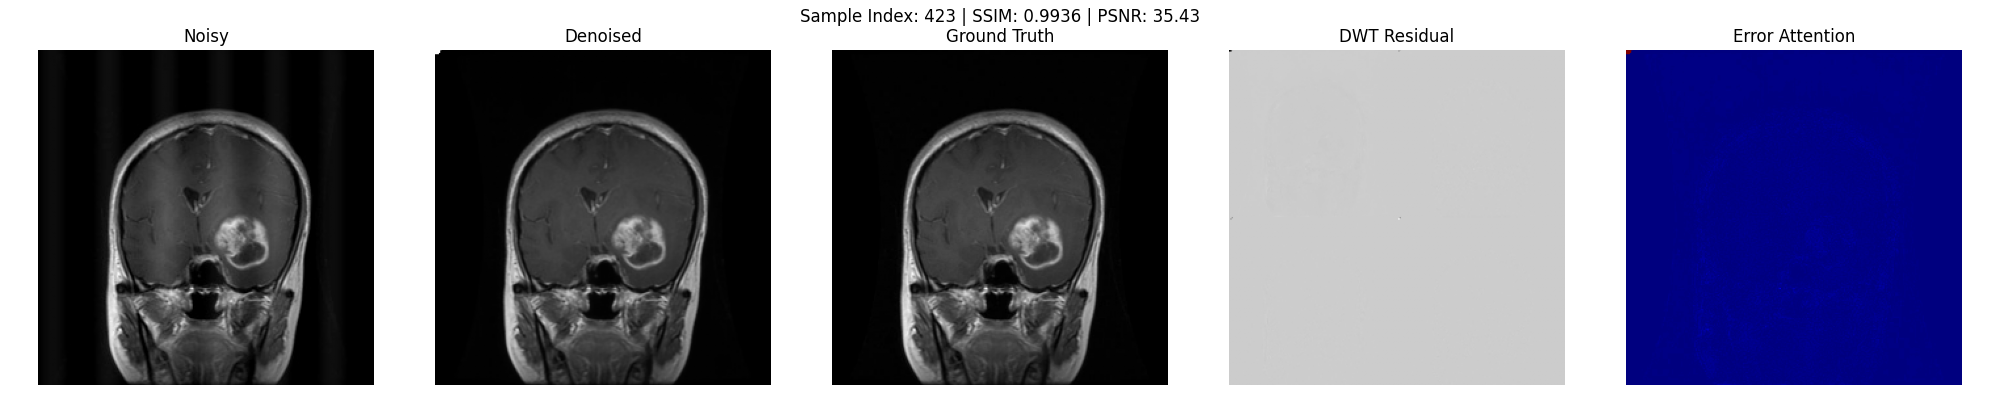

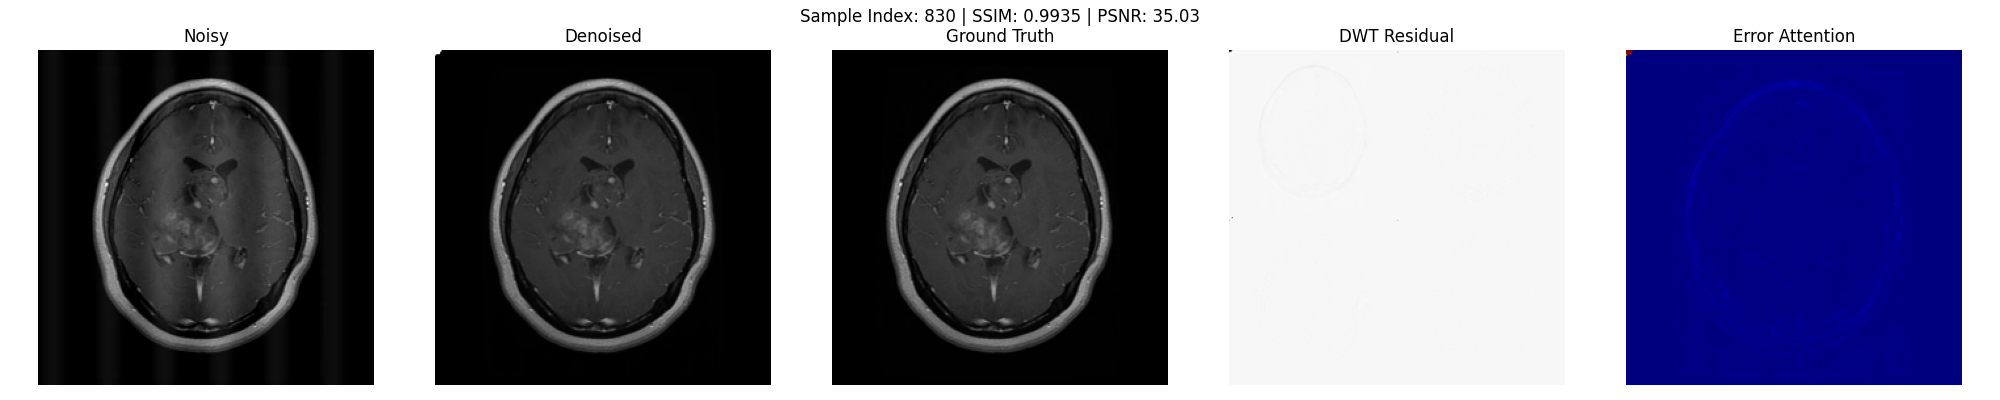

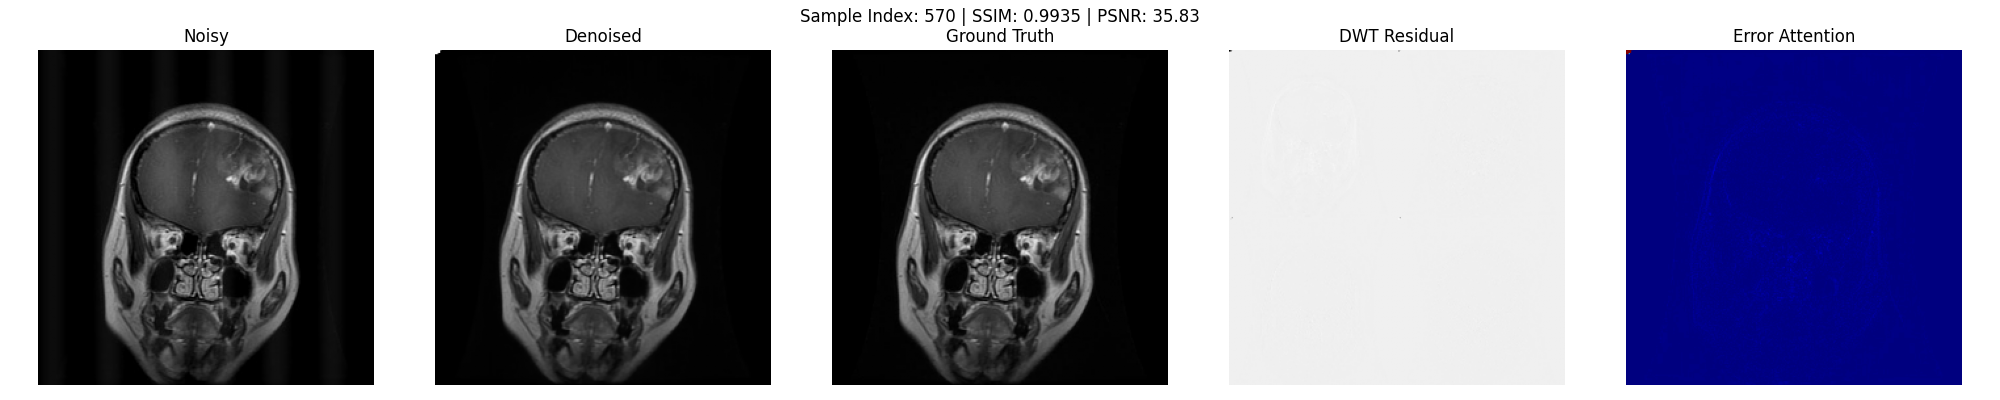

In [ ]:
# ===========================
#  Cell 7.1: Advanced Frequency & Attention Visualization (PERIODIC)
# ===========================

import torch
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
import pywt
import pandas as pd
from IPython.display import Image, display

# --- Paths for saving visualizations ---
VIS_DIR = "/content/drive/MyDrive/Final RI/results/periodic/advanced_visualizations"
os.makedirs(VIS_DIR, exist_ok=True)

# --- Define directories ---
OUTPUT_DIR = "/content/drive/MyDrive/Final RI/results/periodic"
DENOISED_DIR = os.path.join(OUTPUT_DIR, "denoised_images")
NOISY_DIR    = "/content/drive/MyDrive/Final RI/single_noise_outputs/single_noise_outputs_periodic"
CLEAN_DIR    = "/content/drive/MyDrive/Final RI/glioma"

# --- Load metrics CSV ---
csv_path = os.path.join(OUTPUT_DIR, "metrics_periodic.csv")
metrics_df = pd.read_csv(csv_path)

# --- Function: Frequency-domain residual map (DWT) ---
def frequency_residual_map(residual):
    coeffs2 = pywt.dwt2(residual, 'haar')
    LL, (LH, HL, HH) = coeffs2
    res_map = np.stack([LL, LH, HL, HH], axis=-1)
    res_map = (res_map - res_map.min()) / (res_map.max() - res_map.min() + 1e-8)
    top = np.hstack([res_map[:,:,0], res_map[:,:,1]])
    bottom = np.hstack([res_map[:,:,2], res_map[:,:,3]])
    combined = np.vstack([top, bottom])
    return combined

# --- Function: Error-guided attention map ---
def error_attention_map(denoised, clean):
    err = np.abs(clean - denoised)
    err_map = (err - err.min()) / (err.max() - err.min() + 1e-8)
    cmap = plt.get_cmap('jet')
    heatmap = cmap(err_map)[:,:,:3]  # Drop alpha channel
    return heatmap

# --- Pick top 3 SSIM samples ---
top_indices = metrics_df.sort_values("SSIM", ascending=False).head(3).index.tolist()
all_noisy_files = sorted(os.listdir(NOISY_DIR))

for idx in top_indices:
    base_name = all_noisy_files[idx]
    noisy_path    = os.path.join(NOISY_DIR, base_name)
    clean_path    = os.path.join(CLEAN_DIR, base_name)
    denoised_path = os.path.join(DENOISED_DIR, f"denoised_{idx:03d}.png")

    # Load images
    noisy    = cv2.imread(noisy_path, cv2.IMREAD_GRAYSCALE)/255.0
    clean    = cv2.imread(clean_path, cv2.IMREAD_GRAYSCALE)/255.0
    denoised = cv2.imread(denoised_path, cv2.IMREAD_GRAYSCALE)/255.0

    # Resize for consistency
    noisy    = cv2.resize(noisy, (256,256))
    clean    = cv2.resize(clean, (256,256))
    denoised = cv2.resize(denoised, (256,256))

    # Residual and maps
    residual = clean - denoised
    freq_map = frequency_residual_map(residual)
    att_map  = error_attention_map(denoised, clean)

    # Plot
    fig, axes = plt.subplots(1, 5, figsize=(20,4))
    axes[0].imshow(noisy, cmap='gray'); axes[0].set_title("Noisy"); axes[0].axis('off')
    axes[1].imshow(denoised, cmap='gray'); axes[1].set_title("Denoised"); axes[1].axis('off')
    axes[2].imshow(clean, cmap='gray'); axes[2].set_title("Ground Truth"); axes[2].axis('off')
    axes[3].imshow(freq_map, cmap='gray'); axes[3].set_title("DWT Residual"); axes[3].axis('off')
    axes[4].imshow(att_map); axes[4].set_title("Error Attention"); axes[4].axis('off')

    ssim_val = metrics_df.loc[idx, "SSIM"]
    psnr_val = metrics_df.loc[idx, "PSNR"]
    plt.suptitle(f"Sample Index: {idx} | SSIM: {ssim_val:.4f} | PSNR: {psnr_val:.2f}")
    plt.tight_layout()

    # Save figure
    save_path = os.path.join(VIS_DIR, f"sample_{idx:03d}_advanced.png")
    plt.savefig(save_path)
    plt.close()
    display(Image(filename=save_path))


In [ ]:
# ===========================
#  Cell 7.2: Batch Frequency & Error-Attention Maps (ALL – PERIODIC)
# ===========================

import os
import cv2
import numpy as np
import pywt
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm

# Define OUTPUT_DIR explicitly for this cell
OUTPUT_DIR = "/content/drive/MyDrive/Final RI/results/periodic"

# Define directories (added for fix)
NOISY_DIR    = "/content/drive/MyDrive/Final RI/single_noise_outputs/single_noise_outputs_periodic"
CLEAN_DIR    = "/content/drive/MyDrive/Final RI/glioma"
DENOISED_DIR = os.path.join(OUTPUT_DIR, "denoised_images") # Defined earlier in Cell 7, but useful here too

SAVE_DIR = os.path.join(OUTPUT_DIR, "advanced_visualizations_all")
os.makedirs(SAVE_DIR, exist_ok=True)

metrics_df = pd.read_csv(os.path.join(OUTPUT_DIR, "metrics_periodic.csv"))
all_indices = metrics_df["index"].tolist()
all_noisy_files = sorted(os.listdir(NOISY_DIR))

def frequency_residual_map(residual):
    LL, (LH, HL, HH) = pywt.dwt2(residual, 'haar')
    res_map = np.stack([LL, LH, HL, HH], axis=-1)
    res_map = (res_map - res_map.min()) / (res_map.max() - res_map.min() + 1e-8)
    return np.block([[res_map[:,:,0], res_map[:,:,1]],
                     [res_map[:,:,2], res_map[:,:,3]]])

def error_attention_map(denoised, clean):
    err = np.abs(clean - denoised)
    err = (err - err.min()) / (err.max() - err.min() + 1e-8)
    return plt.get_cmap('jet')(err)[:,:,:3]

for idx in tqdm(all_indices, desc=" Generating frequency & attention maps"):
    base_name = all_noisy_files[idx]
    noisy_path    = os.path.join(NOISY_DIR, base_name)
    clean_path    = os.path.join(CLEAN_DIR, base_name)
    denoised_path = os.path.join(DENOISED_DIR, f"denoised_{idx:03d}.png")

    if not (os.path.exists(noisy_path) and os.path.exists(clean_path) and os.path.exists(denoised_path)):
        continue

    noisy    = cv2.imread(noisy_path, cv2.IMREAD_GRAYSCALE)/255.0
    clean    = cv2.imread(clean_path, cv2.IMREAD_GRAYSCALE)/255.0
    denoised = cv2.imread(denoised_path, cv2.IMREAD_GRAYSCALE)/255.0

    noisy    = cv2.resize(noisy, (256,256))
    clean    = cv2.resize(clean, (256,256))
    denoised = cv2.resize(denoised, (256,256))

    residual = clean - denoised
    freq_map = frequency_residual_map(residual)
    att_map  = error_attention_map(denoised, clean)

    fig, axes = plt.subplots(1,2, figsize=(8,4))
    axes[0].imshow(freq_map, cmap='gray'); axes[0].set_title("DWT Residual"); axes[0].axis('off')
    axes[1].imshow(att_map); axes[1].set_title("Error Attention"); axes[1].axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, f"sample_{idx:03d}_freq_att.png"))
    plt.close()

print(f" Saved frequency & attention maps for ALL periodic samples at:\n{SAVE_DIR}")

🔍 Generating frequency & attention maps: 100%|██████████| 1297/1297 [25:02<00:00,  1.16s/it]

✅ Saved frequency & attention maps for ALL periodic samples at:
/content/drive/MyDrive/Final RI/results/periodic/advanced_visualizations_all


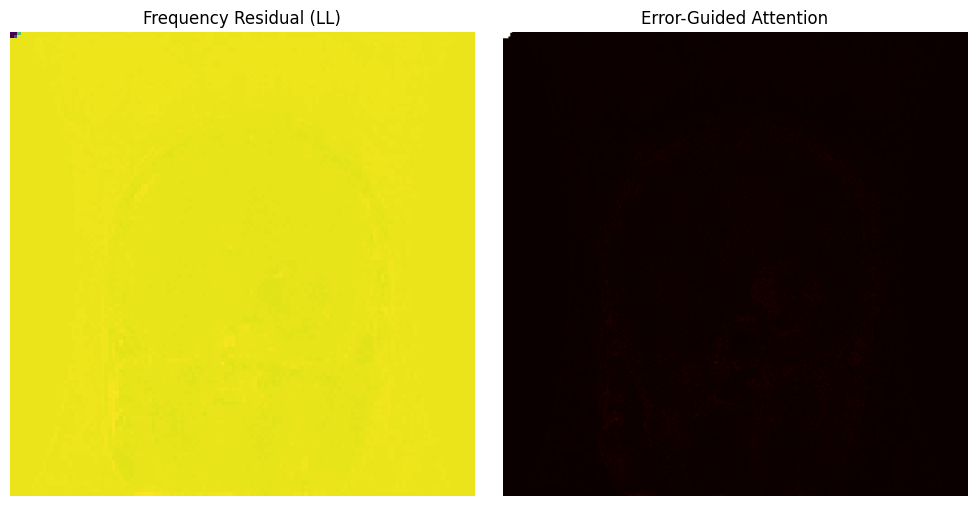

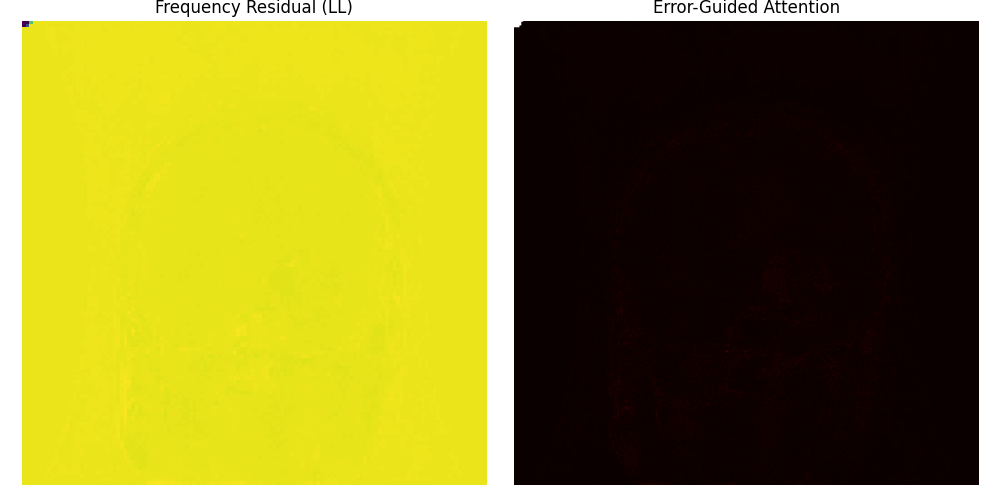

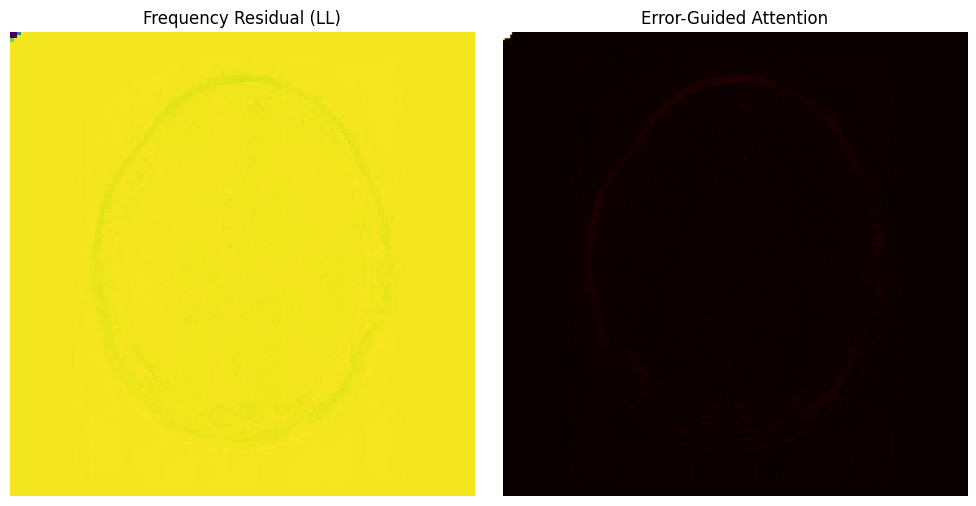

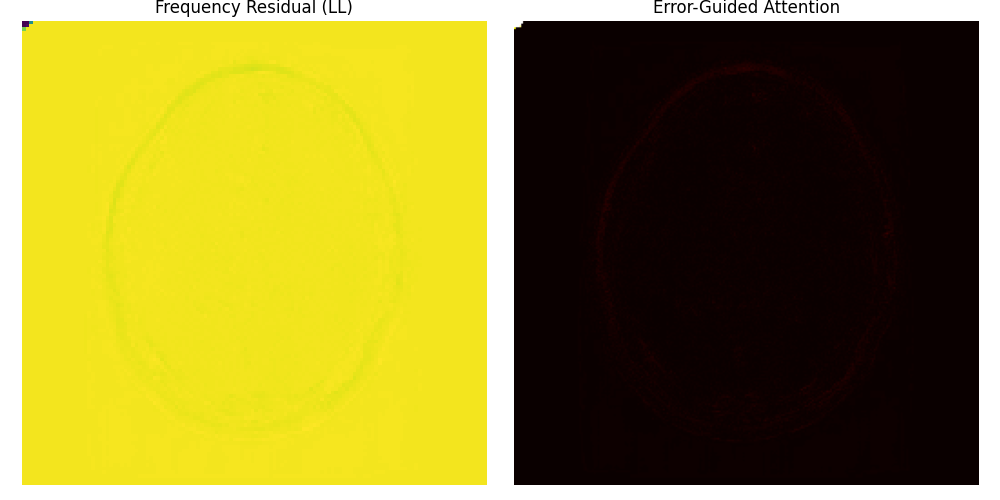

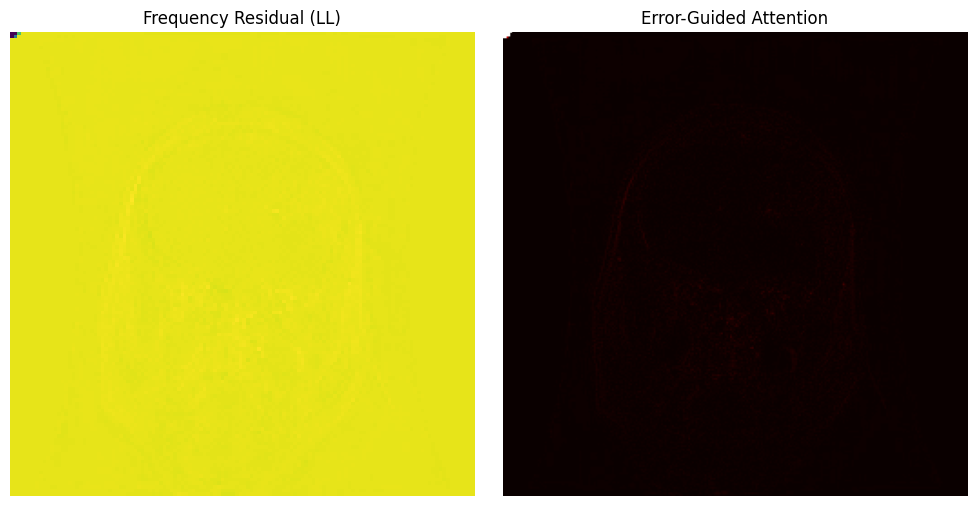

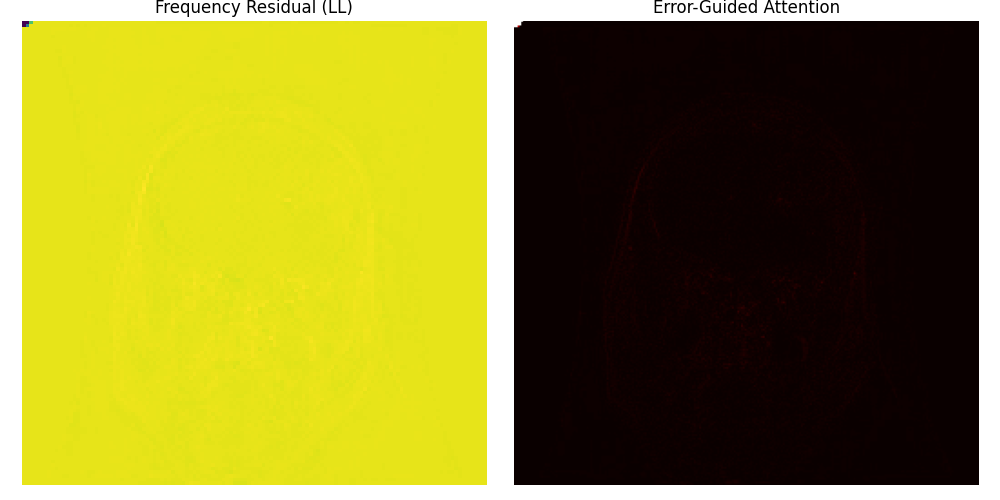

In [ ]:
# ===========================
#  Cell 7.3: Display Frequency Residual & Error Attention Maps (Top-3 – PERIODIC)
# ===========================

from pywt import dwt2
from IPython.display import display, Image

SAVE_DIR = os.path.join(OUTPUT_DIR, "advanced_visualizations_clean")
os.makedirs(SAVE_DIR, exist_ok=True)

all_noisy_files = sorted(os.listdir(NOISY_DIR))
top_indices = metrics_df.sort_values("SSIM", ascending=False).head(3)["index"].tolist()

for idx in top_indices:
    base_name = all_noisy_files[idx]

    clean    = cv2.imread(os.path.join(CLEAN_DIR, base_name), 0)/255.0
    denoised = cv2.imread(os.path.join(DENOISED_DIR, f"denoised_{idx:03d}.png"), 0)/255.0

    clean    = cv2.resize(clean, (256,256))
    denoised = cv2.resize(denoised, (256,256))

    residual = clean - denoised
    LL, _ = dwt2(residual, 'haar')
    freq_map = (LL - LL.min()) / (LL.max() - LL.min() + 1e-8)

    err_map = np.abs(residual)
    err_map = (err_map - err_map.min()) / (err_map.max() - err_map.min() + 1e-8)

    fig, ax = plt.subplots(1,2, figsize=(10,5))
    ax[0].imshow(freq_map, cmap='viridis'); ax[0].set_title(f"Frequency Residual (LL)"); ax[0].axis('off')
    ax[1].imshow(err_map, cmap='hot'); ax[1].set_title("Error-Guided Attention"); ax[1].axis('off')

    plt.tight_layout()
    save_path = os.path.join(SAVE_DIR, f"sample_{idx:03d}_advanced.png")
    plt.savefig(save_path)
    plt.show()
    display(Image(filename=save_path))


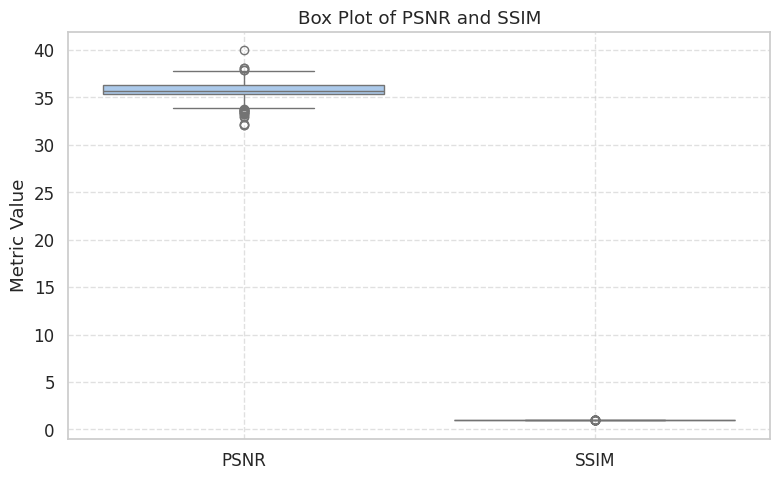

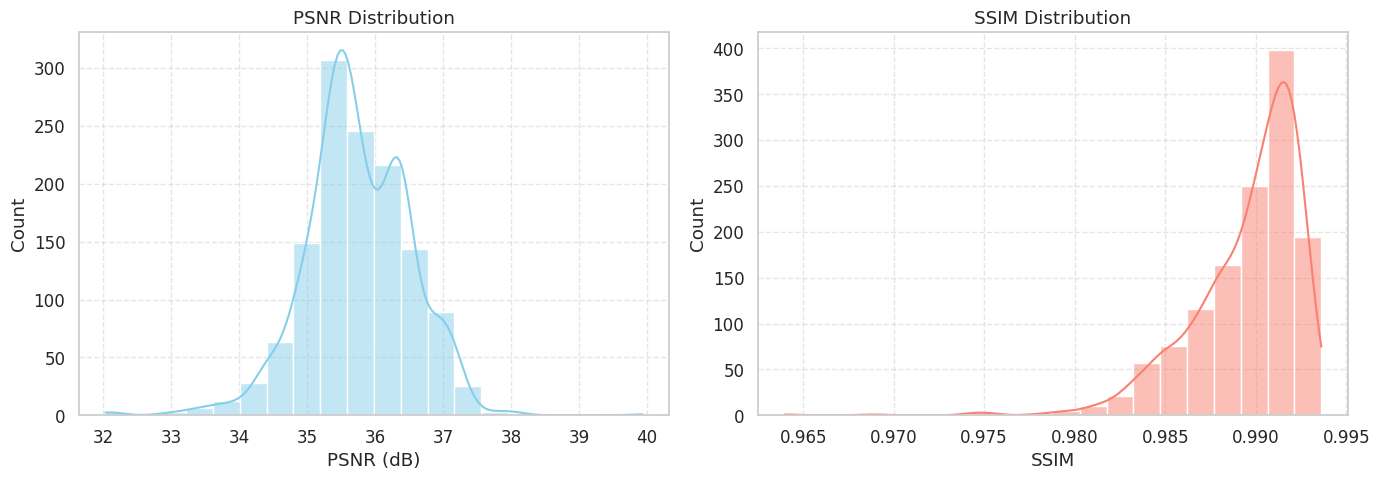

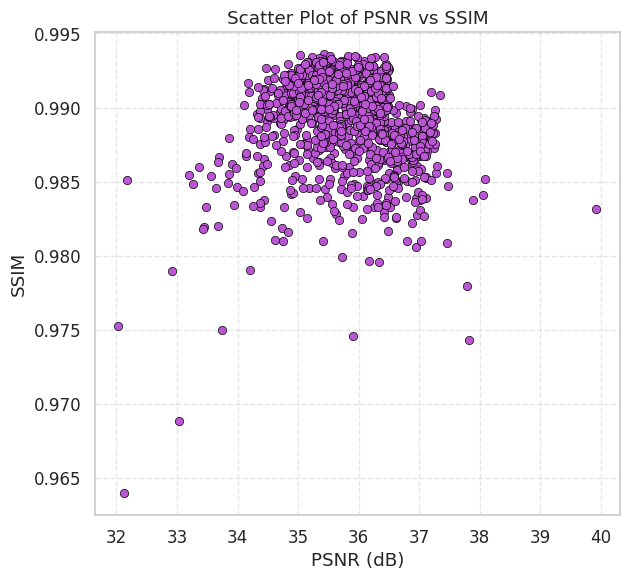


📊 Summary Statistics:


,PSNR,SSIM
mean,35.744573,0.989514
median,35.678874,0.990337
std,0.769822,0.003020


In [ ]:
# ===========================
#  Cell 8: PSNR/SSIM Visualization and Statistical Summary
# ===========================

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Create output directory for visualizations ---
CLINICAL_DIR = os.path.join(OUTPUT_DIR, "clinical_panels")
os.makedirs(CLINICAL_DIR, exist_ok=True)

# --- Load evaluation metrics ---
df = pd.read_csv(os.path.join(OUTPUT_DIR, "metrics_periodic.csv"))

# Set Seaborn style
sns.set(style="whitegrid", font_scale=1.1)

# --- Boxplot for PSNR and SSIM ---
plt.figure(figsize=(8, 5))
sns.boxplot(data=df[["PSNR", "SSIM"]], palette="pastel")
plt.title("Box Plot of PSNR and SSIM")
plt.ylabel("Metric Value")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(CLINICAL_DIR, "boxplot_psnr_ssim.png"))
plt.show()

# --- Histograms with KDE for PSNR and SSIM ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["PSNR"], bins=20, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title("PSNR Distribution")
axes[0].set_xlabel("PSNR (dB)")
axes[0].grid(True, linestyle='--', alpha=0.5)

sns.histplot(df["SSIM"], bins=20, kde=True, color='salmon', ax=axes[1])
axes[1].set_title("SSIM Distribution")
axes[1].set_xlabel("SSIM")
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(CLINICAL_DIR, "histograms_psnr_ssim.png"))
plt.show()

# --- Scatter Plot: PSNR vs SSIM ---
plt.figure(figsize=(6.5, 6))
sns.scatterplot(x="PSNR", y="SSIM", data=df, color='mediumorchid', edgecolor='black')
plt.title("Scatter Plot of PSNR vs SSIM")
plt.xlabel("PSNR (dB)")
plt.ylabel("SSIM")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(CLINICAL_DIR, "scatter_psnr_vs_ssim.png"))
plt.show()

# --- Summary Statistics ---
summary_stats = df[["PSNR", "SSIM"]].agg(['mean', 'median', 'std'])
summary_stats.to_csv(os.path.join(CLINICAL_DIR, "summary_statistics.csv"))

# --- Display Summary Statistics Neatly ---
print("\n Summary Statistics:")
display(summary_stats.round(6))  # For Colab/Jupyter visual display


In [2]:
# ===========================
#  Runtime Restore (Periodic-Only Experiment)
# ===========================

import torch
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.utils import make_grid
from skimage.metrics import peak_signal_noise_ratio as compute_psnr
from skimage.metrics import structural_similarity as compute_ssim
import os, glob

# --- Reload Generator Definition ---
class UNetGenerator(torch.nn.Module):
    def __init__(self, in_channels=1, out_channels=1, latent_dim=256):
        super().__init__()
        def conv_block(in_c, out_c, k=3, s=1, p=1):
            return torch.nn.Sequential(
                torch.nn.Conv2d(in_c, out_c, k, s, p),
                torch.nn.InstanceNorm2d(out_c),
                torch.nn.LeakyReLU(0.2, inplace=True)
            )
        self.enc1 = conv_block(in_channels, 64)
        self.enc2 = conv_block(64, 128)
        self.enc3 = conv_block(128, 256)
        self.enc4 = conv_block(256, 512)
        self.pool = torch.nn.MaxPool2d(2)

        self.flatten = torch.nn.Flatten()
        self.fc_mu = torch.nn.Linear(512 * 16 * 16, latent_dim)
        self.fc_logvar = torch.nn.Linear(512 * 16 * 16, latent_dim)
        self.fc_decoder = torch.nn.Linear(latent_dim, 512 * 16 * 16)
        self.unflatten = torch.nn.Unflatten(1, (512, 16, 16))

        self.up1 = torch.nn.ConvTranspose2d(512, 256, 2, 2)
        self.dec1 = conv_block(512, 256)
        self.up2 = torch.nn.ConvTranspose2d(256, 128, 2, 2)
        self.dec2 = conv_block(256, 128)
        self.up3 = torch.nn.ConvTranspose2d(128, 64, 2, 2)
        self.dec3 = conv_block(128, 64)
        self.out_conv = torch.nn.Conv2d(64, out_channels, 1)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        e4_pool = self.pool(e4)

        flat = self.flatten(e4_pool)
        mu = self.fc_mu(flat)
        logvar = self.fc_logvar(flat)
        z = self.reparameterize(mu, logvar)
        z = self.unflatten(self.fc_decoder(z))
        z = torch.nn.functional.interpolate(z, size=(32, 32), mode='bilinear', align_corners=False)

        d1 = self.up1(z)
        d1 = self.dec1(torch.cat([d1, e3], dim=1))
        d2 = self.up2(d1)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))
        d3 = self.up3(d2)
        d3 = self.dec3(torch.cat([d3, e1], dim=1))
        return torch.sigmoid(self.out_conv(d3)), mu, logvar

# --- Reload Best Generator Weights (Periodic checkpoint path) ---
SAVE_PATH = "/content/drive/MyDrive/Final RI/checkpoints/periodic"
best_model_path = max(glob.glob(os.path.join(SAVE_PATH, "best_generator_epoch*.pt")), key=os.path.getctime)
G = UNetGenerator().cuda()
G.load_state_dict(torch.load(best_model_path))
G.eval()
print(f" Loaded best generator: {os.path.basename(best_model_path)}")

# --- Redefine Dataset Class ---
class MRIDenoisingDataset(Dataset):
    def __init__(self, noisy_dir, clean_dir, transform=None):
        noisy_all = sorted(glob.glob(os.path.join(noisy_dir, "*.*")))
        clean_all = sorted(glob.glob(os.path.join(clean_dir, "*.*")))
        noisy_dict = {os.path.basename(p): p for p in noisy_all}
        clean_dict = {os.path.basename(p): p for p in clean_all}
        common = sorted(set(noisy_dict.keys()) & set(clean_dict.keys()))
        self.noisy = [noisy_dict[f] for f in common]
        self.clean = [clean_dict[f] for f in common]
        self.transform = transform

    def __len__(self): return len(self.noisy)

    def __getitem__(self, idx):
        noisy = cv2.imread(self.noisy[idx], cv2.IMREAD_GRAYSCALE)
        clean = cv2.imread(self.clean[idx], cv2.IMREAD_GRAYSCALE)
        noisy = cv2.resize(noisy, (256, 256)).astype(np.float32) / 255.0
        clean = cv2.resize(clean, (256, 256)).astype(np.float32) / 255.0
        if self.transform:
            noisy = self.transform(noisy)
            clean = self.transform(clean)
        return noisy, clean

# --- Load val_loader again (Periodic paths) ---
transform = transforms.ToTensor()
val_loader = DataLoader(
    MRIDenoisingDataset(
        "/content/drive/MyDrive/Final RI/single_noise_outputs/single_noise_outputs_periodic",
        "/content/drive/MyDrive/Final RI/glioma",
        transform
    ),
    batch_size=1, shuffle=False
)

# --- Reload Top-10 SSIM indices from Periodic metrics ---
OUTPUT_DIR = "/content/drive/MyDrive/Final RI/results/periodic"
metrics_df = pd.read_csv(os.path.join(OUTPUT_DIR, "metrics_periodic.csv"))
selected_samples = metrics_df.sort_values("SSIM", ascending=False).head(10)["index"].tolist()
print(" Selected Top 10 Samples (by SSIM):", selected_samples)


✅ Loaded best generator: best_generator_epoch25_ssim0.9895.pt
📊 Selected Top 10 Samples (by SSIM): [423, 830, 570, 811, 559, 516, 743, 709, 778, 602]


/tmp/ipython-input-3984162832.py:65: UserWarning: Glyph 128266 (\N{SPEAKER WITH THREE SOUND WAVES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3984162832.py:65: UserWarning: Glyph 129532 (\N{BAR OF SOAP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3984162832.py:65: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3984162832.py:66: UserWarning: Glyph 128266 (\N{SPEAKER WITH THREE SOUND WAVES}) missing from font(s) DejaVu Sans.
  plt.savefig(final_path)
/tmp/ipython-input-3984162832.py:66: UserWarning: Glyph 129532 (\N{BAR OF SOAP}) missing from font(s) DejaVu Sans.
  plt.savefig(final_path)
/tmp/ipython-input-3984162832.py:66: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.savefig(final_path)


✅ Saved full visualization: /content/drive/MyDrive/Final RI/results/periodic/visualization_panels/top10_visualization.png


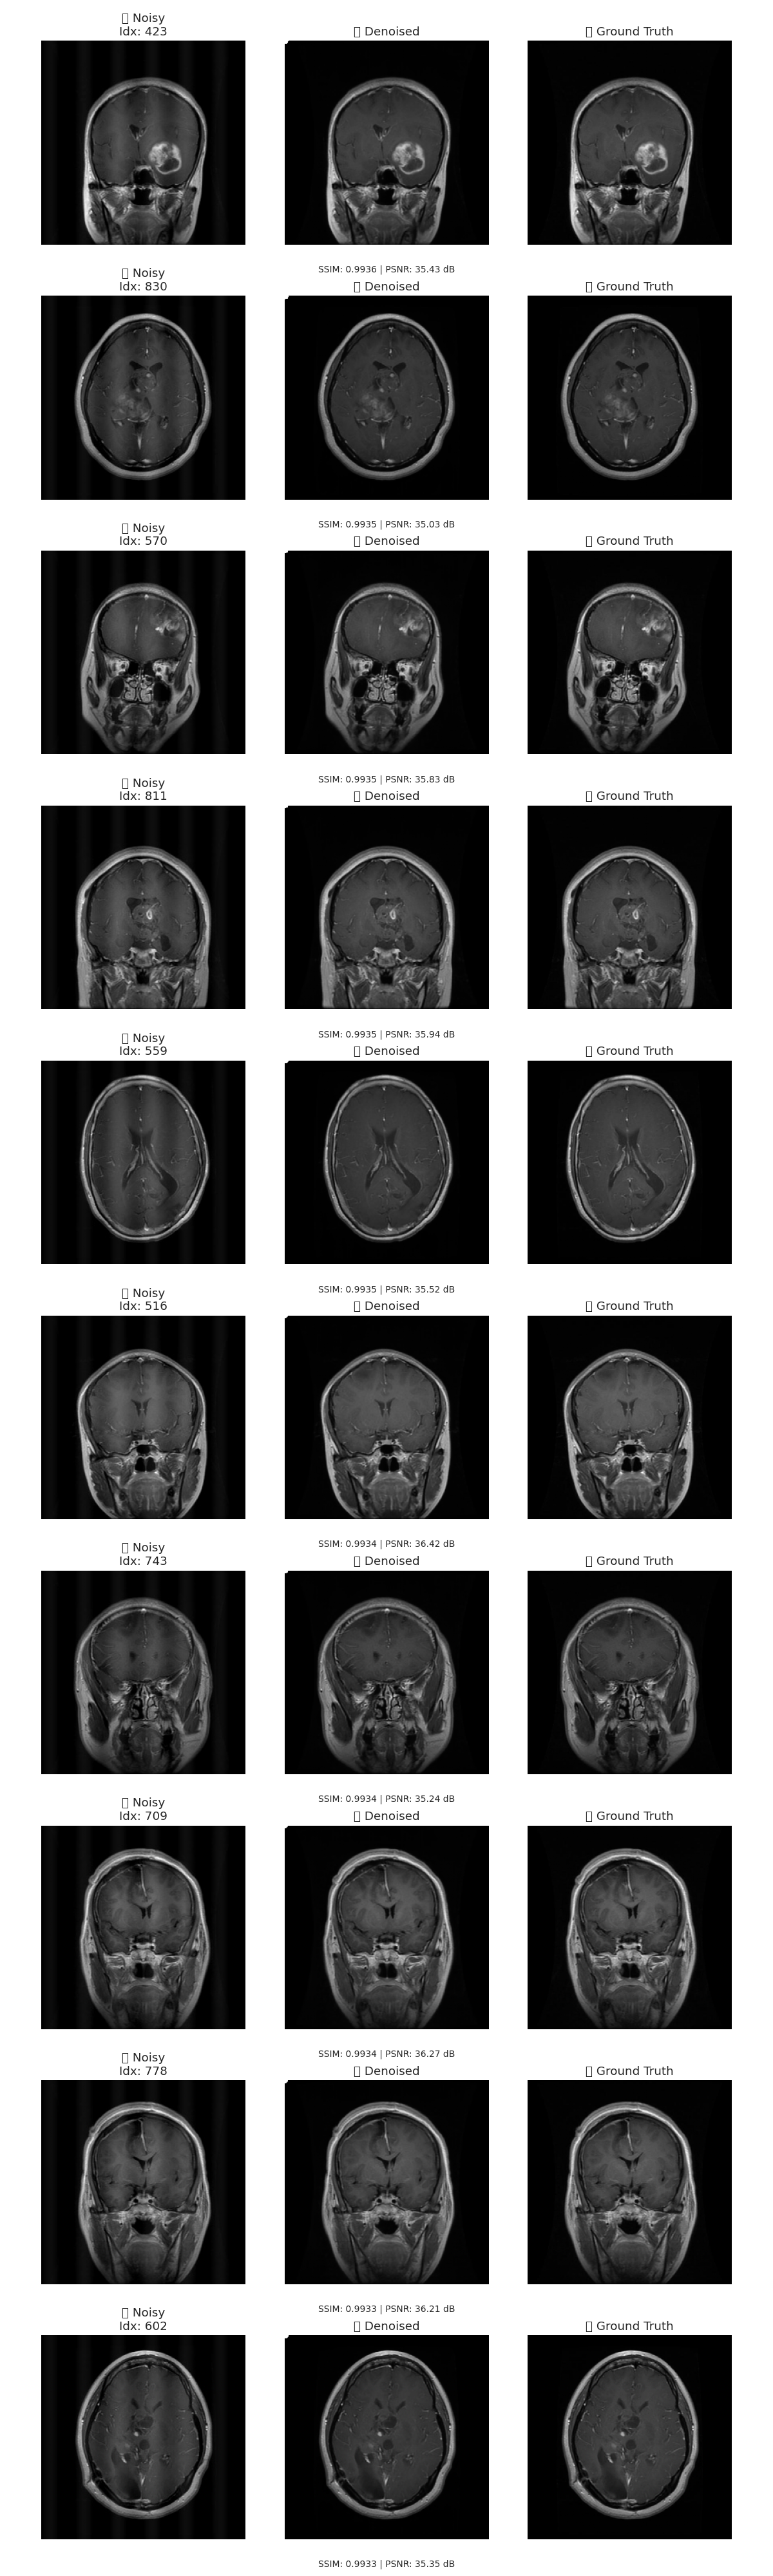

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from IPython.display import Image, display

# Load metrics
metrics_df = pd.read_csv("/content/drive/MyDrive/Final RI/results/periodic/metrics_periodic.csv")

# Top 10 SSIM samples
top_indices = metrics_df.sort_values("SSIM", ascending=False).head(10)["index"].tolist()

# Set paths
denoised_dir = "/content/drive/MyDrive/Final RI/results/periodic/denoised_images"
noisy_dir    = "/content/drive/MyDrive/Final RI/single_noise_outputs/single_noise_outputs_periodic"
clean_dir    = "/content/drive/MyDrive/Final RI/glioma"
save_dir     = "/content/drive/MyDrive/Final RI/results/periodic/visualization_panels"

# Create output folder if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# Create single figure: 10 rows × 3 columns
fig, axes = plt.subplots(nrows=10, ncols=3, figsize=(12, 40))
fig.subplots_adjust(hspace=0.4)

for row_idx, sample_idx in enumerate(top_indices):
    # Align filenames
    base_name = sorted(os.listdir(noisy_dir))[sample_idx]
    noisy_path    = os.path.join(noisy_dir, base_name)
    clean_path    = os.path.join(clean_dir, base_name)
    denoised_path = os.path.join(denoised_dir, f"denoised_{sample_idx:03d}.png")

    # Read images
    noisy    = cv2.imread(noisy_path, cv2.IMREAD_GRAYSCALE)
    clean    = cv2.imread(clean_path, cv2.IMREAD_GRAYSCALE)
    denoised = cv2.imread(denoised_path, cv2.IMREAD_GRAYSCALE)

    # Resize and normalize
    noisy    = cv2.resize(noisy, (256, 256)) / 255.0
    clean    = cv2.resize(clean, (256, 256)) / 255.0
    denoised = cv2.resize(denoised, (256, 256)) / 255.0

    # Plot each in its column
    axes[row_idx, 0].imshow(noisy, cmap='gray')
    axes[row_idx, 0].set_title(f" Noisy\nIdx: {sample_idx}")
    axes[row_idx, 0].axis('off')

    axes[row_idx, 1].imshow(denoised, cmap='gray')
    axes[row_idx, 1].set_title(" Denoised")
    axes[row_idx, 1].axis('off')

    axes[row_idx, 2].imshow(clean, cmap='gray')
    axes[row_idx, 2].set_title(" Ground Truth")
    axes[row_idx, 2].axis('off')

    # Add SSIM and PSNR as text under row
    ssim = metrics_df.loc[sample_idx, "SSIM"]
    psnr = metrics_df.loc[sample_idx, "PSNR"]
    axes[row_idx, 1].text(0.5, -0.1, f"SSIM: {ssim:.4f} | PSNR: {psnr:.2f} dB",
                          fontsize=10, ha='center', va='top', transform=axes[row_idx, 1].transAxes)

# Save full grid as one image
final_path = os.path.join(save_dir, "top10_visualization.png")
plt.tight_layout()
plt.savefig(final_path)
plt.close()

#  Display the saved image in Colab
print(f" Saved full visualization: {final_path}")
display(Image(filename=final_path))


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Saved: /content/drive/MyDrive/Final RI/results/periodic/visualization_panels/top10_visualization.png


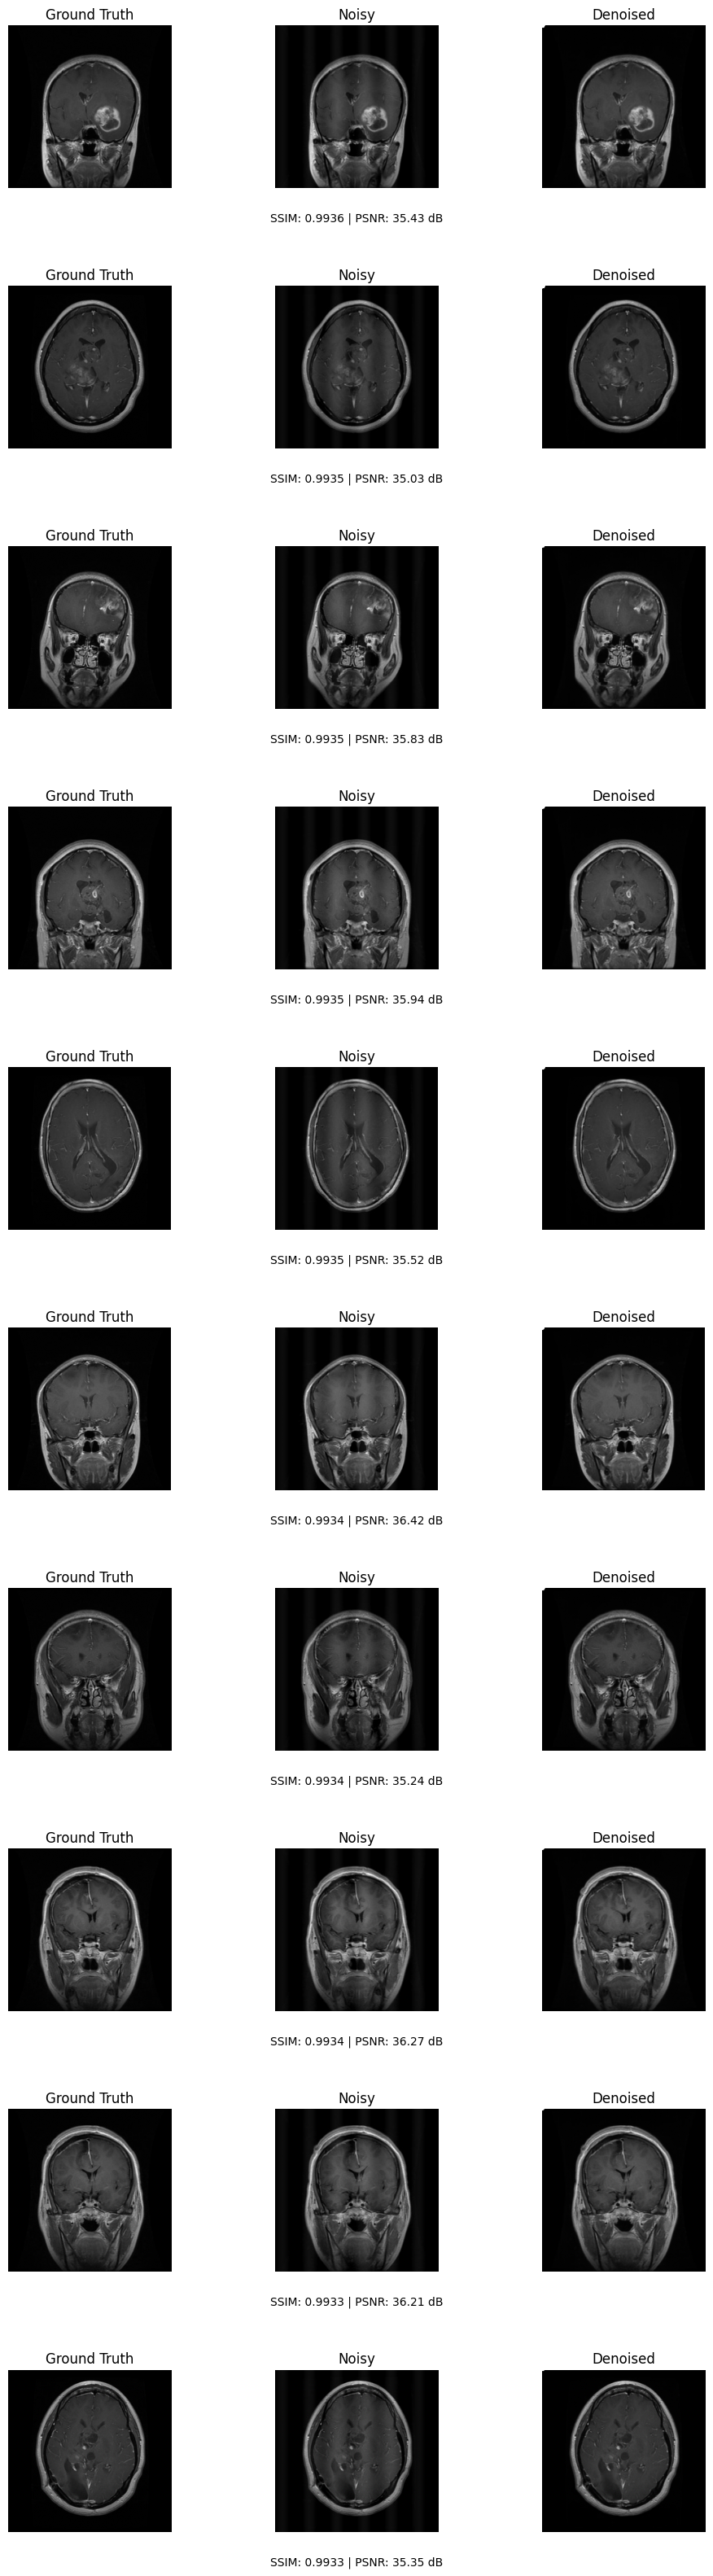

In [3]:
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import os
from IPython.display import Image, display

# =========================
# Load metrics
# =========================
metrics_df = pd.read_csv("/content/drive/MyDrive/Final RI/results/periodic/metrics_periodic.csv")

# Top 10 SSIM samples
top_indices = metrics_df.sort_values("SSIM", ascending=False).head(10)["index"].tolist()

# =========================
# Paths
# =========================
denoised_dir = "/content/drive/MyDrive/Final RI/results/periodic/denoised_images"
noisy_dir    = "/content/drive/MyDrive/Final RI/single_noise_outputs/single_noise_outputs_periodic"
clean_dir    = "/content/drive/MyDrive/Final RI/glioma"
save_dir     = "/content/drive/MyDrive/Final RI/results/periodic/visualization_panels"

os.makedirs(save_dir, exist_ok=True)

# Only load image files (more robust)
noisy_files = sorted([
    f for f in os.listdir(noisy_dir)
    if f.lower().endswith((".png", ".jpg", ".jpeg", ".tif", ".tiff"))
])

# =========================
# Image loader (NO resize, NO modification)
# =========================
def load_image(path):
    if not os.path.exists(path):
        print("File not found:", path)
        return None

    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print("Could not load:", path)
        return None

    return img  # return original pixels only


# =========================
# Create panel
# =========================
fig, axes = plt.subplots(nrows=10, ncols=3, figsize=(12, 40))
plt.subplots_adjust(hspace=0.6, wspace=0.2)

for row_idx, sample_idx in enumerate(top_indices):

    if sample_idx >= len(noisy_files):
        print("Index out of range:", sample_idx)
        continue

    base_name = noisy_files[sample_idx]

    noisy_path    = os.path.join(noisy_dir, base_name)
    clean_path    = os.path.join(clean_dir, base_name)
    denoised_path = os.path.join(denoised_dir, f"denoised_{sample_idx:03d}.png")

    # Load images exactly as saved
    noisy    = load_image(noisy_path)
    clean    = load_image(clean_path)
    denoised = load_image(denoised_path)

    images = [clean, noisy, denoised]
    titles = ["Ground Truth", "Noisy", "Denoised"]

    for col in range(3):
        axes[row_idx, col].axis("off")

        if images[col] is not None:
            axes[row_idx, col].imshow(images[col], cmap="gray", vmin=0, vmax=255)
        else:
            axes[row_idx, col].text(
                0.5, 0.5, "Missing Image",
                ha="center", va="center"
            )

        axes[row_idx, col].set_title(titles[col], fontsize=12)

    # Show SSIM + PSNR
    ssim = metrics_df.loc[sample_idx, "SSIM"]
    psnr = metrics_df.loc[sample_idx, "PSNR"]

    axes[row_idx, 1].text(
        0.5, -0.2,
        f"SSIM: {ssim:.4f} | PSNR: {psnr:.2f} dB",
        fontsize=10,
        ha="center",
        transform=axes[row_idx, 1].transAxes
    )

# =========================
# Save + display
# =========================
final_path = os.path.join(save_dir, "top10_visualization.png")

plt.savefig(final_path, bbox_inches="tight")
plt.close()

print("Saved:", final_path)
display(Image(filename=final_path))